# BigGAN + MidJourney: Cat 4 Classes, IQA + CLIP + XGBoost / MLP

Notebook ini menggabungkan dua keluarga fitur: **NR-IQA** (`PIQE`, `BRISQUE`, `NIQE`) dan **CLIP image embedding**. Setup data tetap sama seperti notebook `08`?`11`.


In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyiqa
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import CLIPModel, CLIPProcessor
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
MULTICLASS_ROOT = PROJECT_ROOT / "data" / "raw" / "genimage_multiclass_balanced"
DATA_ROOT = MULTICLASS_ROOT / "genimage"
DATA_ROOTS = {
    "BigGAN": DATA_ROOT / "BigGAN" / "train",
    "MidJourney": DATA_ROOT / "MidJourney" / "train",
}
MANIFEST_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_manifest.csv"
CLASS_TABLE_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_classes.csv"
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
print("Data root:", DATA_ROOT.resolve())
print("Manifest source:", MANIFEST_SOURCE.resolve())
SUBSET_NAME = "biggan_midjourney_multiclass_train"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_multiclass_train.csv"
CLIP_OUT = PROJECT_ROOT / "artifacts" / "features_clip_biggan_midjourney_multiclass_train.csv"
IQA_OUT = PROJECT_ROOT / "artifacts" / "features_iqa_biggan_midjourney_multiclass_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_multiclass_iqa_clip.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_multiclass_iqa_clip.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_multiclass_iqa_clip.csv"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_OUT_DIM = 64


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage
Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv


## 1. Audit data per generator

In [2]:
manifest_source = pd.read_csv(MANIFEST_SOURCE)
class_table = pd.read_csv(CLASS_TABLE_SOURCE)

manifest_source["path_exists"] = manifest_source["path"].map(lambda p: Path(p).is_file())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("Class table:", CLASS_TABLE_SOURCE.resolve())
print("Manifest shape:", manifest_source.shape)
print("Jumlah kelas:", manifest_source["imagenet_id"].nunique())
print("Semua path ada:", bool(manifest_source["path_exists"].all()))

display(class_table.head(10))
display(
    manifest_source
    .groupby(["generator", "class_name"])
    .size()
    .rename("count")
    .reset_index()
)
display(
    manifest_source
    .groupby(["generator", "class_name", "imagenet_id", "wordnet_id", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .describe(include="all")
)


Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
Class table: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_classes.csv
Manifest shape: (8000, 16)
Jumlah kelas: 40
Semua path ada: True


,class_id,class_id_str,wnid,label
0,0,0,n01440764,tench
1,1,1,n01443537,goldfish
2,2,2,n01484850,great_white_shark
3,3,3,n01491361,tiger_shark
4,4,4,n01494475,hammerhead
5,5,5,n01496331,electric_ray
6,6,6,n01498041,stingray
7,7,7,n01514668,cock
8,8,8,n01514859,hen
9,9,9,n01518878,ostrich


,generator,class_name,count
0,BigGAN,ai,2000
1,BigGAN,nature,2000
2,MidJourney,ai,2000
3,MidJourney,nature,2000


,generator,class_name,imagenet_id,wordnet_id,content_label,count
count,160,160,160.000000,160,160,160.0
unique,2,2,NaN,40,40,NaN
top,BigGAN,ai,NaN,n01440764,tench,NaN
freq,80,80,NaN,4,4,NaN
mean,NaN,NaN,112.925000,NaN,NaN,50.0
std,NaN,NaN,131.508019,NaN,NaN,0.0
min,NaN,NaN,0.000000,NaN,NaN,50.0
25%,NaN,NaN,9.750000,NaN,NaN,50.0
50%,NaN,NaN,59.500000,NaN,NaN,50.0
75%,NaN,NaN,207.250000,NaN,NaN,50.0


## 2. Bangun manifest gabungan untuk 4 class kucing yang sama


In [3]:
manifest = pd.read_csv(MANIFEST_SOURCE).copy()
manifest["subset_name"] = "biggan_midjourney_multiclass_train"
manifest["split"] = "train"
manifest["path"] = manifest["path"].map(lambda p: str(Path(p).resolve()))

missing_paths = manifest.loc[~manifest["path"].map(lambda p: Path(p).is_file()), "path"].head()
if len(missing_paths):
    raise FileNotFoundError(
        "Ada path manifest yang tidak ditemukan, contoh: "
        + str(missing_paths.tolist())
    )

manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())
display(
    manifest
    .groupby(["generator", "class_name", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .head(20)
)


Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_multiclass_train.csv
Manifest shape: (8000, 15)


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,content_label,imagenet_id,wordnet_id,is_real,y_ai
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1


,generator,y_ai,count
0,BigGAN,0,2000
1,BigGAN,1,2000
2,MidJourney,0,2000
3,MidJourney,1,2000


,generator,class_name,content_label,count
0,BigGAN,ai,Chesapeake_Bay_retriever,50
1,BigGAN,ai,Chihuahua,50
2,BigGAN,ai,Egyptian_cat,50
3,BigGAN,ai,German_short-haired_pointer,50
4,BigGAN,ai,Labrador_retriever,50
5,BigGAN,ai,Persian_cat,50
6,BigGAN,ai,Siamese_cat,50
7,BigGAN,ai,ambulance,50
8,BigGAN,ai,beach_wagon,50
9,BigGAN,ai,black_swan,50


## 3. Ekstraksi fitur

In [4]:
if IQA_OUT.exists():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Loaded existing IQA features later; skip IQA metric initialization.")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    metric_piqe = pyiqa.create_metric("piqe", device=device)
    metric_brisque = pyiqa.create_metric("brisque", device=device)
    metric_niqe = pyiqa.create_metric("niqe", device=device)
    print("device:", device)


Loaded existing IQA features later; skip IQA metric initialization.


In [5]:
if IQA_OUT.exists():
    iqa_df = pd.read_csv(IQA_OUT)
    print("Loaded existing IQA features:", IQA_OUT.resolve())
else:
    from PIL import Image

    IQA_CACHE_DIR = IQA_OUT.parent / "_iqa_safe_images_multiclass"
    IQA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    MIN_IQA_SIDE = 256

    def make_iqa_safe_image(path: str) -> str:
        """NIQE needs enough spatial support; upsample small images to avoid zero-size blocks."""
        src = Path(path)
        img = Image.open(src).convert("RGB")
        w, h = img.size

        if min(w, h) >= MIN_IQA_SIDE:
            return str(src)

        scale = MIN_IQA_SIDE / min(w, h)
        new_size = (int(round(w * scale)), int(round(h * scale)))
        safe_path = IQA_CACHE_DIR / f"{src.stem}_{new_size[0]}x{new_size[1]}.png"

        if not safe_path.exists():
            img = img.resize(new_size, Image.Resampling.BICUBIC)
            img.save(safe_path)

        return str(safe_path)

    def extract_iqa_scores(path: str):
        safe_path = make_iqa_safe_image(path)
        with torch.no_grad():
            piqe = float(metric_piqe(safe_path).item())
            brisque = float(metric_brisque(safe_path).item())
            niqe = float(metric_niqe(safe_path).item())
        return {
            "piqe": piqe,
            "brisque": brisque,
            "niqe": niqe,
        }

    iqa_rows = []
    iqa_errors = []

    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        try:
            scores = extract_iqa_scores(row.path)
            iqa_rows.append({"image_id": row.image_id, **scores})
        except Exception as exc:
            iqa_errors.append({
                "image_id": row.image_id,
                "path": row.path,
                "error": repr(exc),
            })

        if idx % 100 == 0:
            print(f"Processed IQA {idx}/{len(manifest)} images")

    if iqa_errors:
        err_df = pd.DataFrame(iqa_errors)
        err_out = IQA_OUT.parent / "features_iqa_errors_biggan_midjourney_multiclass_train.csv"
        err_df.to_csv(err_out, index=False)
        print("IQA errors:", len(iqa_errors))
        print("Saved IQA error log:", err_out.resolve())
        display(err_df.head())

    if not iqa_rows:
        raise RuntimeError("No IQA features were extracted. Check the IQA error log.")

    iqa_df = pd.DataFrame(iqa_rows)
    iqa_df.to_csv(IQA_OUT, index=False)
    print("Saved IQA features:", IQA_OUT.resolve())

display(iqa_df.head())


Loaded existing IQA features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_iqa_biggan_midjourney_multiclass_train.csv


,image_id,piqe,brisque,niqe
0,BigGAN_ai_000_000000,42.487041,36.240234,4.933562
1,BigGAN_ai_000_000001,50.800961,36.021912,5.641158
2,BigGAN_ai_000_000002,41.170307,44.712158,4.913123
3,BigGAN_ai_000_000003,41.735916,37.302612,5.203913
4,BigGAN_ai_000_000004,41.149288,41.458374,4.682221


## 4. Bangun feature vector

In [6]:
if CLIP_OUT.exists():
    clip_df = pd.read_csv(CLIP_OUT)
    print("Loaded CLIP features:", CLIP_OUT.resolve())
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
    clip_model.eval()
    print("CLIP device:", device)

    def extract_clip_vector(path: str, out_dim: int = 64):
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = clip_model.vision_model(**inputs)
            feats = out.pooler_output
            feats = clip_model.visual_projection(feats)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        vec = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
        if out_dim < vec.shape[0]:
            vec = vec[:out_dim]
        elif out_dim > vec.shape[0]:
            vec = np.concatenate([vec, np.zeros(out_dim - vec.shape[0], dtype=np.float32)])
        return vec

    clip_rows = []
    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        vec = extract_clip_vector(row.path, out_dim=CLIP_OUT_DIM)
        item = {"image_id": row.image_id}
        for i, v in enumerate(vec):
            item[f"clip_feat_{i:03d}"] = float(v)
        clip_rows.append(item)
        if idx % 100 == 0:
            print(f"Processed CLIP {idx}/{len(manifest)} images")

    clip_df = pd.DataFrame(clip_rows)
    clip_df.to_csv(CLIP_OUT, index=False)
    print("Saved CLIP features:", CLIP_OUT.resolve())

display(clip_df.head())


Loaded CLIP features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_clip_biggan_midjourney_multiclass_train.csv


,image_id,clip_feat_000,clip_feat_001,clip_feat_002,clip_feat_003,clip_feat_004,clip_feat_005,clip_feat_006,clip_feat_007,clip_feat_008,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,BigGAN_ai_000_000000,0.023383,0.033415,0.000783,0.000693,0.001556,0.028215,-0.023073,0.015947,0.060079,...,0.033839,0.013861,0.008991,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896
1,BigGAN_ai_000_000001,-0.005320,0.025451,-0.001197,0.040806,0.008424,0.023826,-0.031863,-0.036118,0.093952,...,0.003529,-0.015651,0.038348,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008
2,BigGAN_ai_000_000002,0.018574,0.012184,0.006055,0.021351,-0.015919,-0.043677,-0.025114,0.006281,0.049114,...,0.043169,-0.033627,0.021230,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130
3,BigGAN_ai_000_000003,0.024487,0.034794,-0.013841,-0.000896,0.002640,0.002252,-0.023318,0.002641,0.074824,...,0.037015,-0.001909,-0.009840,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082
4,BigGAN_ai_000_000004,-0.003053,0.005584,0.027832,0.041834,0.018493,-0.015387,-0.031849,-0.006884,0.080148,...,0.007375,-0.012183,0.069066,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019


In [7]:
data = manifest.merge(clip_df, on="image_id", how="inner").merge(iqa_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = [
    c for c in data.columns
    if c.startswith(("fft_", "clip_feat_")) or c in ["piqe", "brisque", "niqe"]
]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (8000, 82)
Feature dims: 67
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_multiclass_iqa_clip.csv


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,...,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063,piqe,brisque,niqe
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.049043,-0.045764,0.022915,0.107769,-0.025100,-0.033920,-0.008896,42.487041,36.240234,4.933562
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.043967,-0.016589,0.021125,0.092690,-0.019105,-0.017591,0.000008,50.800961,36.021912,5.641158
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.031247,-0.043649,-0.004992,0.102849,-0.007372,-0.003672,0.005130,41.170307,44.712158,4.913123
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.044110,-0.047930,0.006833,0.097258,-0.017063,-0.046253,0.008082,41.735916,37.302612,5.203913
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,...,0.075082,-0.045463,0.035869,0.091091,-0.002146,-0.025999,0.006019,41.149288,41.458374,4.682221


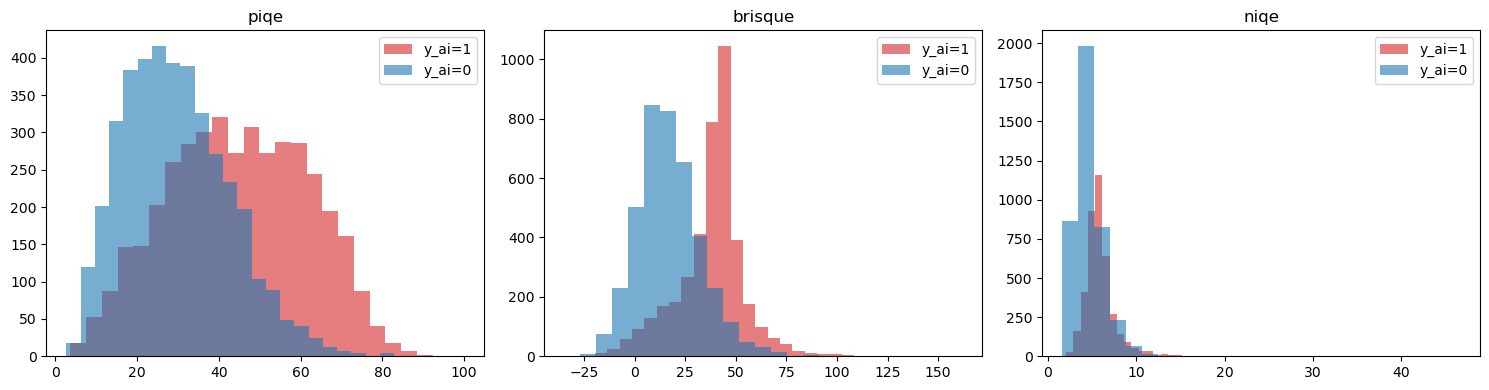

In [8]:
plot_cols = ["piqe", "brisque", "niqe"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, plot_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=25, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Split 80:20 dengan stratifikasi gabungan

In [9]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (6400, 67) (6400,)
Eval: (1600, 67) (1600,)


## 6. Train baseline

In [10]:
MLP_HIDDEN = (128, 64)
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,MLP,0.940625,0.940588,0.985634
1,XGBoost,0.921875,0.921826,0.975580


## 7. Confusion matrix model terbaik

Best model: MLP

              precision    recall  f1-score   support

      nature       0.94      0.94      0.94       800
          ai       0.94      0.94      0.94       800

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



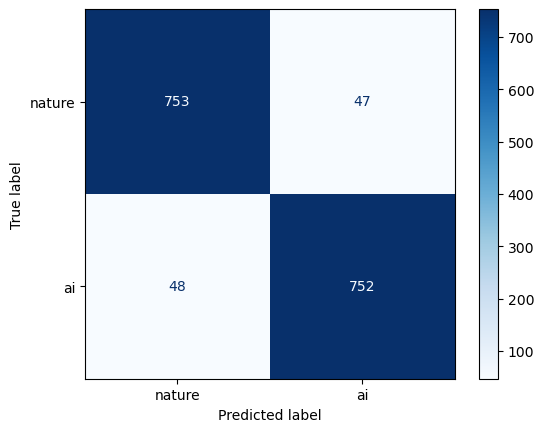

In [11]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [12]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "iqa_plus_clip"
metrics_df["iqa_metrics"] = "piqe,brisque,niqe"
metrics_df["clip_model"] = CLIP_MODEL_NAME
metrics_df["clip_out_dim"] = CLIP_OUT_DIM
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = SUBSET_NAME
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())

Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_multiclass_iqa_clip.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_multiclass_iqa_clip.csv


,model,accuracy,f1,auroc,feature_set,iqa_metrics,clip_model,clip_out_dim,split_protocol,subset_name,n_total,n_train,n_eval
0,MLP,0.940625,0.940588,0.985634,iqa_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600
1,XGBoost,0.921875,0.921826,0.975580,iqa_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,BigGAN_nature_436_003899,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02814533,beach_wagon,0,XGBoost,0.701776,1
1,MidJourney_ai_107_006446,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,107,jellyfish,1,XGBoost,0.356687,0
2,BigGAN_ai_014_001413,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,014,indigo_bunting,1,XGBoost,0.984143,1
3,BigGAN_ai_102_002207,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,102,echidna,1,XGBoost,0.941779,1
4,BigGAN_nature_016_001690,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n01560419,bulbul,0,XGBoost,0.064648,0


## 9. Catatan interpretasi

Notebook ini menguji apakah metrik IQA tradisional masih memberi nilai tambah saat digabung dengan sinyal semantik dari CLIP.